In [24]:
import matplotlib.pyplot as plt
import pandas as pd
import pathlib as path

In [25]:
parent_dir = path.Path.cwd().parent
data = pd.read_csv(parent_dir / "data" / "properties_2016_raw.csv",
                   dtype={
                        'hashottuborspa': 'string',
                        'propertycountylandusecode': 'string',
                        'propertyzoningdesc': 'string',
                        'fireplaceflag': 'string',
                        'taxdelinquencyflag': 'string',
                        }
)

In [26]:
print(data.columns)

Index(['parcelid', 'airconditioningtypeid', 'architecturalstyletypeid',
       'basementsqft', 'bathroomcnt', 'bedroomcnt', 'buildingclasstypeid',
       'buildingqualitytypeid', 'calculatedbathnbr', 'decktypeid',
       'finishedfloor1squarefeet', 'calculatedfinishedsquarefeet',
       'finishedsquarefeet12', 'finishedsquarefeet13', 'finishedsquarefeet15',
       'finishedsquarefeet50', 'finishedsquarefeet6', 'fips', 'fireplacecnt',
       'fullbathcnt', 'garagecarcnt', 'garagetotalsqft', 'hashottuborspa',
       'heatingorsystemtypeid', 'latitude', 'longitude', 'lotsizesquarefeet',
       'poolcnt', 'poolsizesum', 'pooltypeid10', 'pooltypeid2', 'pooltypeid7',
       'propertycountylandusecode', 'propertylandusetypeid',
       'propertyzoningdesc', 'rawcensustractandblock', 'regionidcity',
       'regionidcounty', 'regionidneighborhood', 'regionidzip', 'roomcnt',
       'storytypeid', 'threequarterbathnbr', 'typeconstructiontypeid',
       'unitcnt', 'yardbuildingsqft17', 'yardbuildin

In [27]:
cols = ["longitude", "latitude"]
geo_data = data[cols].dropna(how = "any").sort_values(by = ['latitude', 'longitude'])
geo_data.describe()

,longitude,latitude
count,2.973780e+06,2.973780e+06
mean,-1.182019e+08,3.400147e+07
std,3.453171e+05,2.433812e+05
min,-1.194758e+08,3.332439e+07
25%,-1.183930e+08,3.382768e+07
50%,-1.181725e+08,3.400825e+07
75%,-1.179495e+08,3.416186e+07
max,-1.175543e+08,3.481965e+07


In [28]:
max_latitude = 34.33729521663121 * 1e6 // 1
min_latitude = 33.704608786053 * 1e6 // 1
max_longitude = -118.15541491562345 * 1e6 // 1
min_longitude = -118.66813567797944 * 1e6 // 1

In [29]:
geo_data_la_only = geo_data[(geo_data["longitude"] <= max_longitude) & (geo_data["longitude"] >= min_longitude) &
                            (geo_data["latitude"] <= max_latitude) & (geo_data["latitude"] >= min_latitude)]

In [30]:
geo_data_la_only.describe()

,longitude,latitude
count,1.182066e+06,1.182066e+06
mean,-1.183561e+08,3.404189e+07
std,1.211564e+05,1.500583e+05
min,-1.186681e+08,3.370616e+07
25%,-1.184354e+08,3.392417e+07
50%,-1.183486e+08,3.404623e+07
75%,-1.182618e+08,3.417119e+07
max,-1.181554e+08,3.433001e+07


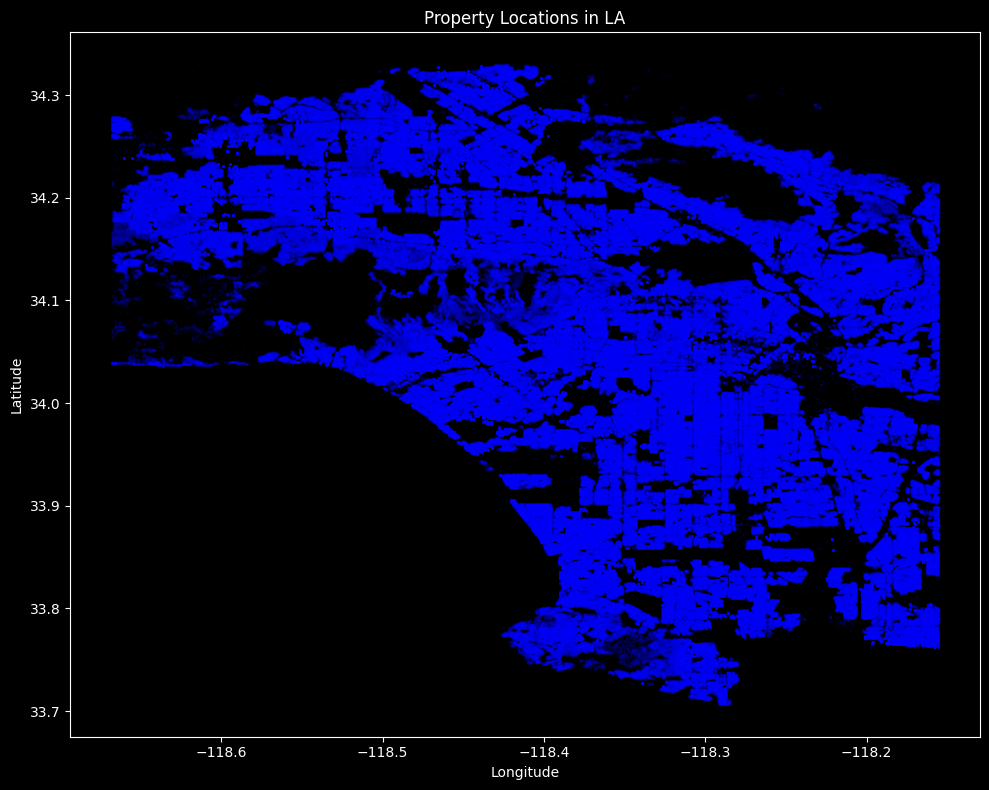

In [31]:
lon = geo_data_la_only['longitude'] / 1e6
lat = geo_data_la_only['latitude'] / 1e6

plt.figure(figsize=(10, 8))

# s=1 makes the dots tiny, alpha=0.1 makes them transparent
plt.scatter(lon, lat, s=1, alpha=0.1, color='blue')

plt.title("Property Locations in LA")
plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.tight_layout()
plt.show()

In [32]:
cols = ["taxvaluedollarcnt", "taxdelinquencyflag", "taxdelinquencyyear", "latitude", "longitude"]
tax_data = data[cols].fillna(value={"taxdelinquencyflag": "N", "taxdelinquencyyear": 0}).sort_values(by=['taxvaluedollarcnt', 'taxdelinquencyyear']).reset_index(drop=True)

late = tax_data[tax_data['taxdelinquencyflag'] == 'Y']
punctual = tax_data.drop(index = late.index)

tax_data.describe()
late["taxdelinquencyyear"].sort_values().unique()

array([ 1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10., 11., 12., 13.,
       14., 15., 79., 82., 84., 86., 87., 88., 90., 91., 92., 93., 94.,
       95., 96., 97., 98., 99.])

In [33]:
not_late = tax_data[tax_data['taxdelinquencyflag'] == 'N']
late_1st_group = tax_data[(tax_data['taxdelinquencyyear'] >= 1) & (tax_data['taxdelinquencyyear'] <= 5)]
late_2nd_group = tax_data[(tax_data['taxdelinquencyyear'] >= 6) & (tax_data['taxdelinquencyyear'] <= 10)]
late_3rd_group = tax_data[(tax_data['taxdelinquencyyear'] >= 11) & (tax_data['taxdelinquencyyear'] <= 15)]
late_last_group = tax_data[tax_data['taxdelinquencyyear'] >= 16]

uniq = tax_data["taxdelinquencyyear"].unique()
uniq.sort()
uniq


array([ 0.,  1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10., 11., 12.,
       13., 14., 15., 79., 82., 84., 86., 87., 88., 90., 91., 92., 93.,
       94., 95., 96., 97., 98., 99.])